INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, sub_networks


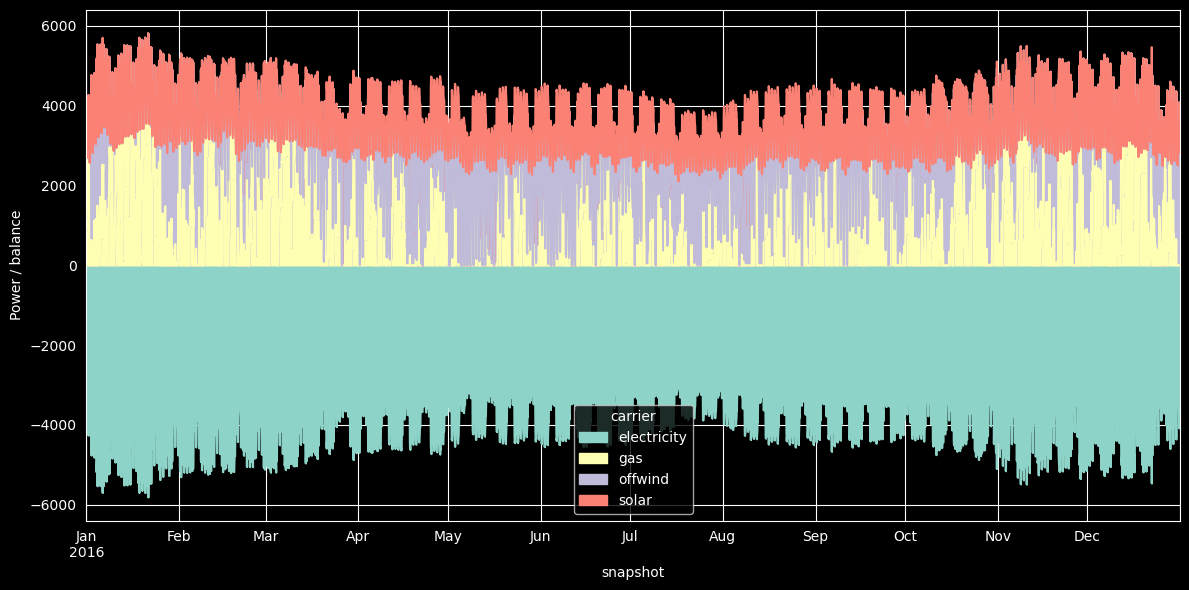

In [9]:
import pypsa
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

MODEL_PATH = "results/regional_network_2016.nc"


def load_network(model_path: str) -> pypsa.Network:
    """
    Load solved PyPSA network.
    """
    return pypsa.Network(model_path)


n = load_network(MODEL_PATH)
balance = n.statistics.energy_balance(aggregate_time=False)

# aggregate by carrier
balance_by_carrier = balance.groupby(level="carrier").sum()

# put time on x-axis
balance_by_carrier_t = balance_by_carrier.T

# drop carriers that are all NaN
balance_by_carrier_t = balance_by_carrier_t.dropna(axis=1, how="all")

# drop carriers that are zero everywhere
balance_by_carrier_t = balance_by_carrier_t.loc[
    :, (balance_by_carrier_t.fillna(0).abs() > 0).any(axis=0)
]

balance_by_carrier_t.plot.area(stacked=True, figsize=(12, 6))
plt.ylabel("Power / balance")
plt.tight_layout()
plt.show()

#balance_simple = balance.groupby(level="carrier").sum()

#balance_simple.T.plot(kind="bar", stacked=, figsize=(12, 6))

#balance.plot()